In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import detrend
from scipy.linalg import svd
from scipy.fft import fft, fftfreq

In [2]:
def calibration(data, bias, matrix=None):
    if matrix is None:
        return data - bias
    calibrated_data = np.dot(matrix, (data - bias).T).T 
    return calibrated_data

raw_df = pd.read_csv('center_sternum.txt', delimiter='\t')
raw_df

,Log Mode,Log Freq,Timestamp,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ,qw,qi,qj,qk
0,5,200,1576222772,947.086,435.662,70.638,-6.824428,-14.244280,1.404580,-454,-490,-178,0.792622,0.254952,-0.553850,-0.000031
1,5,200,1576222772,969.168,387.777,88.877,6.183206,-12.290080,-7.969466,-454,-490,-177,0.736461,0.275124,-0.617969,0.006806
2,5,200,1576222772,989.603,380.335,78.751,11.709920,-4.961832,-7.450382,-454,-490,-177,0.729465,0.275246,-0.626118,0.009827
3,5,200,1576222772,954.894,418.033,88.328,17.877860,2.519084,-5.984733,-454,-492,-176,0.723413,0.277200,-0.632221,0.011383
4,5,200,1576222772,972.096,427.732,99.857,25.221370,5.404580,4.015267,-454,-492,-176,0.721948,0.280007,-0.632679,0.010193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16501,5,200,1576222847,958.493,291.092,-54.290,1.664122,2.305344,-0.671756,-494,-449,-126,0.650810,0.379162,-0.636402,0.166356
16502,5,200,1576222847,954.650,288.042,-49.654,1.480916,2.488550,-0.702290,-494,-450,-125,0.650239,0.379803,-0.636708,0.165960
16503,5,200,1576222847,967.338,290.482,-63.867,1.114504,3.374046,-0.900763,-494,-450,-125,0.649365,0.380627,-0.637227,0.165502
16504,5,200,1576222847,965.630,300.852,-56.242,0.702290,3.664122,-1.587786,-495,-448,-124,0.648973,0.381329,-0.637348,0.164953


In [3]:
offset_gyro = np.array([-2.242224, 2.963463, -0.718397])

calibration_acc = np.array([[1.000966,     -0.002326418,-0.0006995499],
                            [-0.002326379,  0.9787045,  -0.001540918],
                            [-0.0006995811,-0.001540928, 1.00403]])
offset_acc = np.array([-3.929942, -13.74679, 60.67546])

calibration_magn = np.array([[0.9192851, -0.02325168, 0.003480837],
                             [-0.02325175, 0.914876, 0.004257396],
                             [0.003481006, 0.004257583, 0.8748001]])

offset_magn = np.array([-95.67974, -244.9142, 17.71132])

Data taking lasted: 82.525 seconds


,Time,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ
0,0.000,942.993735,410.533833,130.532698,-9.066652,-11.280817,0.686183,-488.782344,-660.256760,-145.262950
1,0.005,965.195708,363.589092,148.903540,3.940982,-9.326617,-8.687863,-488.778863,-660.252503,-144.388150
2,0.010,985.674845,356.273637,138.733904,9.467696,-1.998369,-8.168779,-488.778863,-660.252503,-144.388150
3,0.015,950.837915,393.234828,148.315692,15.635636,5.482547,-6.703130,-488.728879,-662.077997,-143.521865
4,0.020,968.025903,402.669499,159.864174,22.979146,8.368043,3.296870,-488.728879,-662.077997,-143.521865
...,...,...,...,...,...,...,...,...,...,...
16501,82.505,954.835478,269.208490,5.316030,-0.578102,5.268807,-1.390153,-526.326063,-621.595390,-99.738024
16502,82.510,950.992618,266.225238,9.978102,-0.761308,5.452013,-1.420687,-526.299331,-622.506008,-98.867482
16503,82.515,963.697141,268.605661,-4.304813,-1.127720,6.337509,-1.619160,-526.299331,-622.506008,-98.867482
16504,82.520,961.958032,278.747051,3.336131,-1.539934,6.627585,-2.306183,-527.261638,-620.648747,-97.987647


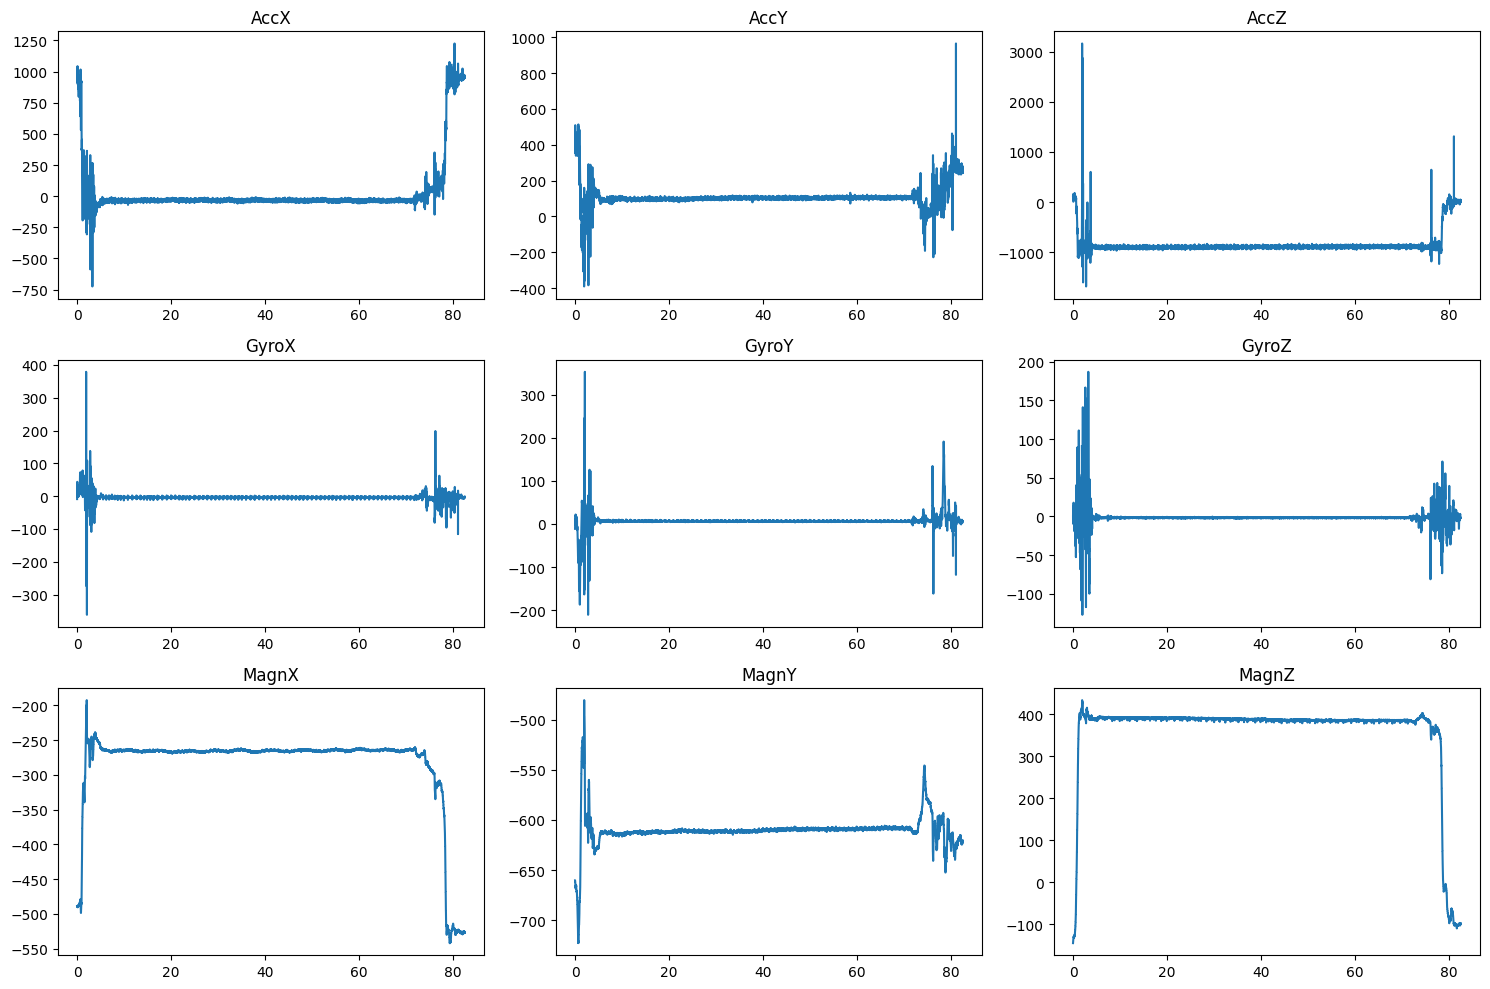

In [4]:
LOG_FREQ = raw_df['Log Freq'][0]

raw_df = raw_df.drop(columns=['Log Freq', 'Log Mode', 'Timestamp', 'qw', 'qi', 'qj', 'qk'])

time = np.arange(raw_df.shape[0])/LOG_FREQ
print(f'Data taking lasted: {time[-1]} seconds')

raw_df.insert(0, 'Time', time)

raw_df[['AccX', 'AccY', 'AccZ']] = np.dot(raw_df[['AccX', 'AccY', 'AccZ']] + offset_acc.T, calibration_acc.T)
raw_df[['GyroX', 'GyroY', 'GyroZ']] = raw_df[['GyroX', 'GyroY', 'GyroZ']] + offset_gyro.T
raw_df[['MagnX', 'MagnY', 'MagnZ']] = np.dot(raw_df[['MagnX', 'MagnY', 'MagnZ']] + offset_magn.T, calibration_magn.T)

display(raw_df)

fig, axs = plt.subplots(3, 3, figsize=(15, 10))
for i, col in enumerate(raw_df.columns[1:]):
    axs[i//3, i%3].plot(raw_df['Time'], raw_df[col])
    axs[i//3, i%3].set_title(col)
plt.tight_layout()
plt.show()

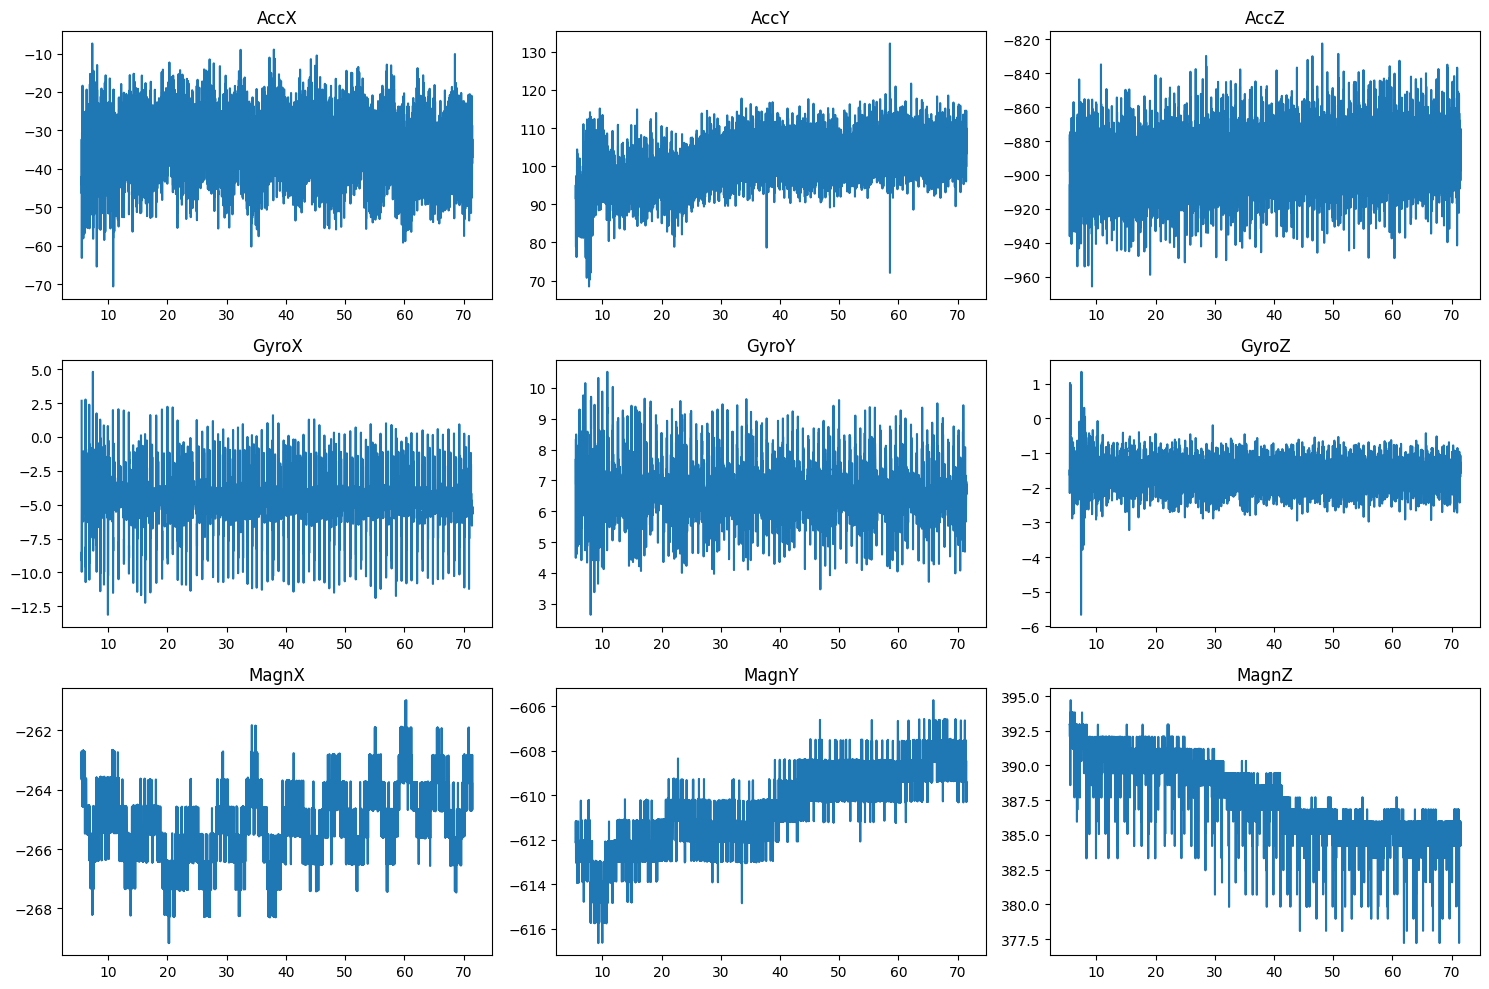

In [5]:
df = raw_df[(raw_df['Time'] > 5.5) & (raw_df['Time'] < 71.5)]

fig, axs = plt.subplots(3, 3, figsize=(15, 10))
for i, col in enumerate(df.columns[1:]):
    axs[i//3, i%3].plot(df['Time'], df[col])
    axs[i//3, i%3].set_title(col)
plt.tight_layout()
plt.show()

/tmp/ipykernel_9364/1441352835.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = detrend(df[col])


,Time,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ
1101,5.505,-10.304781,-3.710784,-6.423061,6.917568,0.931636,-0.064890,3.156265,1.149839,1.176199
1102,5.510,-10.472448,-1.336786,-36.438138,3.085520,0.259893,0.072518,2.213617,2.087561,1.177596
1103,5.515,-10.172971,-2.731745,-23.208172,-3.799963,-0.060705,-0.599234,2.213506,2.087156,1.178217
1104,5.520,1.285218,-0.284987,-1.601447,-5.708347,-0.793518,-0.217550,3.132680,2.063499,1.182318
1105,5.525,-12.829332,-3.395925,23.461761,-5.036577,-2.243886,0.484744,3.132569,2.063094,1.182938
...,...,...,...,...,...,...,...,...,...,...
14295,71.475,3.099261,0.369090,-13.138315,-0.709255,0.391251,0.322972,0.697991,-2.377166,2.367376
14296,71.480,-1.800346,-0.913768,12.711731,-0.892447,0.253858,0.536716,0.697880,-2.377571,2.367997
14297,71.485,1.093308,-1.889180,-17.912674,-0.846633,0.101199,0.261911,0.667556,-1.471615,0.623274
14298,71.490,-0.070843,-4.176999,-4.190307,-1.274101,0.376020,0.032907,0.667445,-1.472020,0.623895


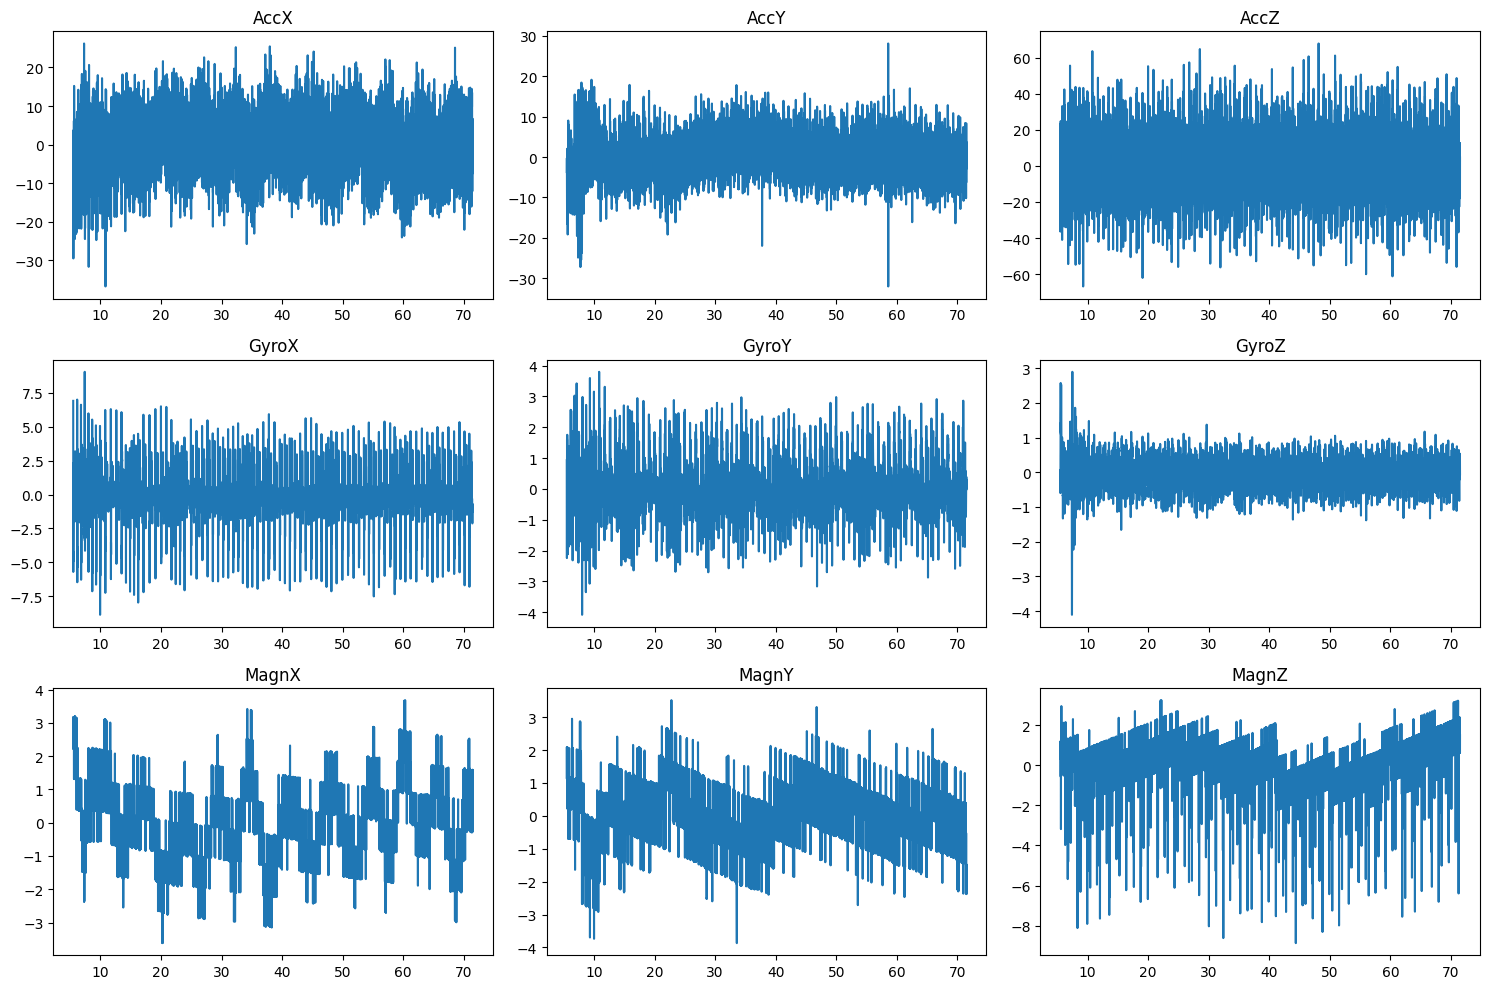

In [6]:
# apply detrend to each entry of the dataframe

for col in df.columns[1:]:
    df[col] = detrend(df[col])

display(df)

# plot
fig, axs = plt.subplots(3, 3, figsize=(15, 10))
for i, col in enumerate(df.columns[1:]):
    axs[i//3, i%3].plot(df['Time'], df[col])
    axs[i//3, i%3].set_title(col)
plt.tight_layout()
plt.show()

In [7]:
def apply_pca(df, columns):
    '''
    Apply PCA to the given dataframe and columns using SVD.
    
    Parameters:
    df: the input dataframe
    columns: the columns to apply PCA to
    
    Returns:
    projected_data: data projection on the principal components
    variability: the variability of each principal component (descending order)
    principal_axes: the principal components ordered by variability (descending order)
    '''
    
    X = df[columns].to_numpy()
    N = X.shape[0]

    X_centered = X - np.mean(X, axis=0) # we center the data also if we have already done detrending, to be sure that the mean is zero

    U, sigma, Vt = svd(X_centered)
    
    eigenvalues = (sigma**2) / (N - 1)
    cov_trace = np.sum(eigenvalues)
    variability = eigenvalues / cov_trace
    
    pc = Vt.T 
    
    projected_data = np.dot(X_centered, pc)
    
    return projected_data, variability, pc

low_cut = 0.08 # Hz 
high_cut = 0.8

Variability of each PC: [0.76826453 0.15386232 0.07787315]
Respiratory Peak: 0.20 Hz (11.8 breaths/min)


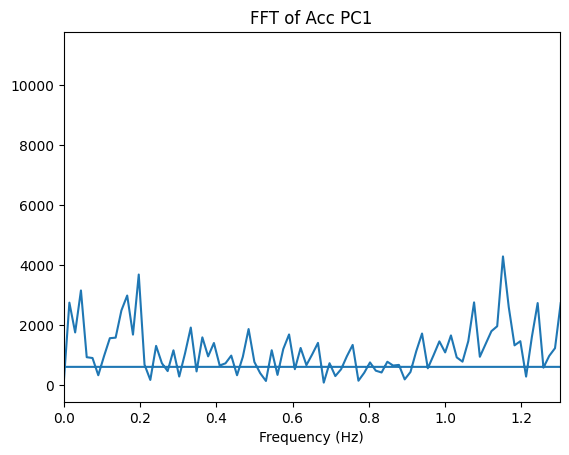

In [8]:
acc, variability_acc, pc_acc = apply_pca(df, ['AccX', 'AccY', 'AccZ'])
print(f'Variability of each PC: {variability_acc}')

acc1 = acc[:, 0]
acc_fft = fft(acc1)
freq_acc = fftfreq(len(acc1), d=1/200)

respiratory_mask = (freq_acc >= low_cut) & (freq_acc <= high_cut)

freqs_in_range = freq_acc[respiratory_mask]
peak_freq_resp = freqs_in_range[np.argmax(np.abs(acc_fft[respiratory_mask]))]
print(f'Respiratory Peak: {peak_freq_resp:.2f} Hz ({peak_freq_resp * 60:.1f} breaths/min)')

plt.plot(freq_acc, np.abs(acc_fft))
plt.xlim(0, high_cut+0.5)
plt.title('FFT of Acc PC1')
plt.xlabel('Frequency (Hz)')
plt.show()

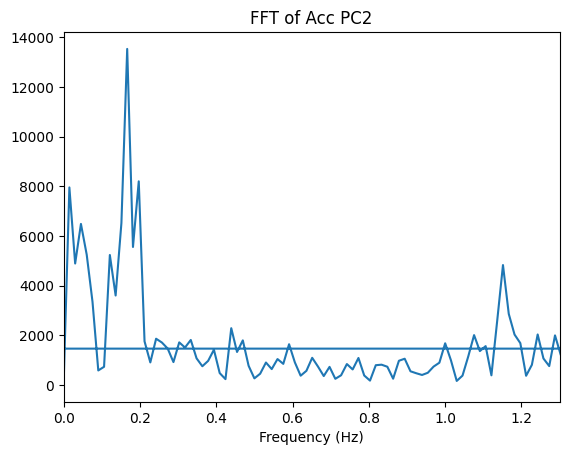

In [9]:
acc2 = acc[:, 1]
acc2_fft = fft(acc2)
freq_acc2 = fftfreq(len(acc2), d=1/200)

plt.plot(freq_acc2, np.abs(acc2_fft))
plt.xlim(0, high_cut+0.5)
plt.title('FFT of Acc PC2')
plt.xlabel('Frequency (Hz)')
plt.show()

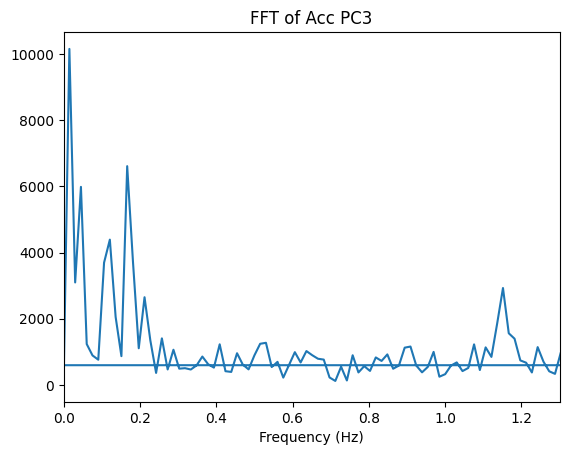

In [10]:
acc3 = acc[:, 2]
acc3_fft = fft(acc3)
freq_acc3 = fftfreq(len(acc3), d=1/200)

plt.plot(freq_acc3, np.abs(acc3_fft))
plt.xlim(0, high_cut+0.5)
plt.title('FFT of Acc PC3')
plt.xlabel('Frequency (Hz)')
plt.show()

Variability of each PC: [0.79714689 0.1592931  0.04356001]
Respiratory Peak: 0.21 Hz (12.7 breaths/min)


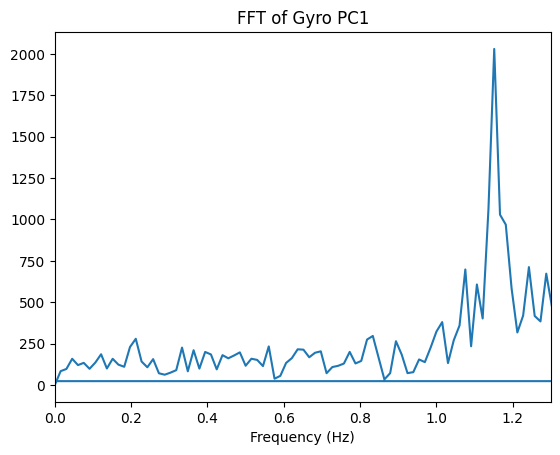

In [11]:
gyro, variability_gyro, pc_gyro = apply_pca(df, ['GyroX', 'GyroY', 'GyroZ'])
print(f'Variability of each PC: {variability_gyro}')

gyro1 = gyro[:, 0]
gyro_fft = fft(gyro1)
freq_gyro = fftfreq(len(gyro1), d=1/200)

respiratory_mask_gyro = (freq_gyro >= low_cut) & (freq_gyro <= high_cut)

freqs_in_range_gyro = freq_gyro[respiratory_mask_gyro]
peak_freq_resp_gyro = freqs_in_range_gyro[np.argmax(np.abs(gyro_fft[respiratory_mask_gyro]))]
print(f'Respiratory Peak: {peak_freq_resp_gyro:.2f} Hz ({peak_freq_resp_gyro * 60:.1f} breaths/min)')

plt.plot(freq_gyro, np.abs(gyro_fft))
plt.xlim(0, high_cut+0.5)
plt.title('FFT of Gyro PC1')
plt.xlabel('Frequency (Hz)')
plt.show()

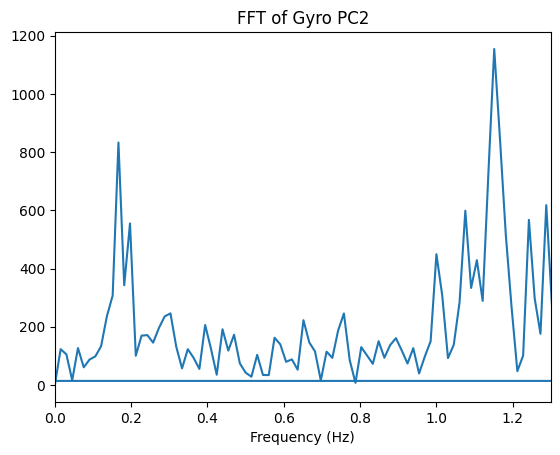

In [12]:
gyro2 = gyro[:, 1]
gyro2_fft = fft(gyro2)

freq_gyro2 = fftfreq(len(gyro2), d=1/200)
plt.plot(freq_gyro2, np.abs(gyro2_fft))
plt.xlim(0, high_cut+0.5)
plt.title('FFT of Gyro PC2')
plt.xlabel('Frequency (Hz)')
plt.show()

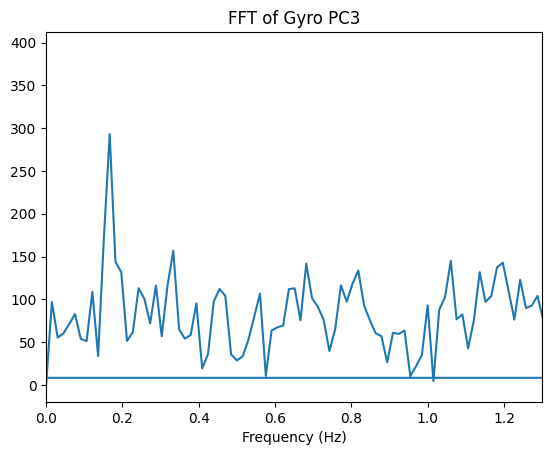

In [13]:
gyro3 = gyro[:, 2]
gyro3_fft = fft(gyro3)
freq_gyro3 = fftfreq(len(gyro3), d=1/200)

plt.plot(freq_gyro3, np.abs(gyro3_fft))
plt.xlim(0, high_cut+0.5)
plt.title('FFT of Gyro PC3')
plt.xlabel('Frequency (Hz)')
plt.show()

Variability of each PC: [0.4307577  0.35985239 0.20938991]
Respiratory Peak: 0.17 Hz (10.0 breaths/min)


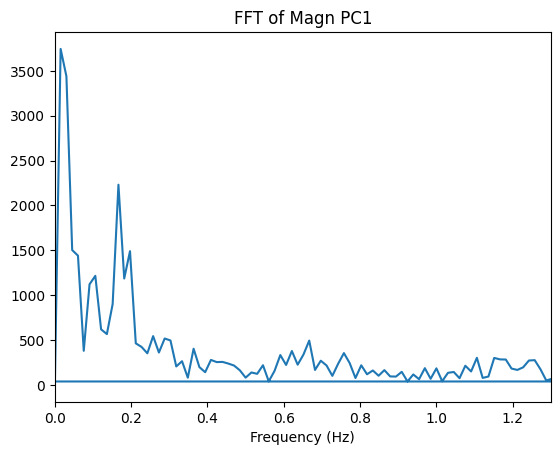

In [14]:
magn, variability_magn, pc_magn = apply_pca(df, ['MagnX', 'MagnY', 'MagnZ'])
print(f'Variability of each PC: {variability_magn}')

magn1 = magn[:, 0]
magn_fft = fft(magn1)
freq_magn = fftfreq(len(magn1), d=1/200)

respiratory_mask_magn = (freq_magn >= low_cut) & (freq_magn <= high_cut)

freqs_in_range_magn = freq_magn[respiratory_mask_magn]
peak_freq_resp_magn = freqs_in_range_magn[np.argmax(np.abs(magn_fft[respiratory_mask_magn]))]
print(f'Respiratory Peak: {peak_freq_resp_magn:.2f} Hz ({peak_freq_resp_magn * 60:.1f} breaths/min)')

plt.plot(freq_magn, np.abs(magn_fft))
plt.xlim(0, high_cut+0.5)
plt.title('FFT of Magn PC1')
plt.xlabel('Frequency (Hz)')
plt.show()

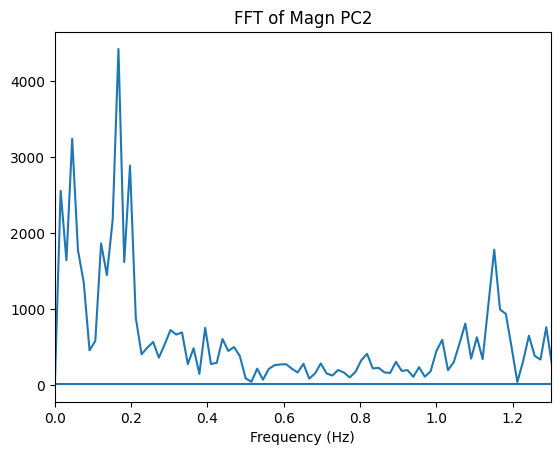

In [15]:
magn2 = magn[:, 1]
magn2_fft = fft(magn2)
freq_magn2 = fftfreq(len(magn2), d=1/200)

plt.plot(freq_magn2, np.abs(magn2_fft))
plt.xlim(0, high_cut+0.5)
plt.title('FFT of Magn PC2')
plt.xlabel('Frequency (Hz)')
plt.show()

## DISCRETE WAVELET TRANSFORM  
Following the work of the [paper](https://www.sciencedirect.com/science/article/pii/S174680941930360X?via%3Dihub) *"Estimation of heart rate and respiratory rate from the seismocardiogram under resting state"*, we apply a **Dyadic-tree Wavelet Decomposition** to extract the respiratory rate. In contrast to standard Fourier Analysis, the Wavelet Transform provides a **signal decomposition in both the time and frequency domains**. This allows for the effective filtering of spurious sensor drifts and high-frequency noise while preserving the exact time localization of kinematic events.

In the DWT framework (implemented via the Mallat Algorithm), **the signal is iteratively decomposed through a series of discrete filters**. As proposed in the referenced paper, a Daubechies 6 wavelet is adopted as its oscillating pattern is similar to the respiratory waveform.

The decomposition runs for $J$ levels. At each level $j$, the signal $s[n]$ is decomposed by the wavelet function and subsequently downsampled by a factor of two ($\downarrow 2$). This process splits the data into two discrete components: the low-frequency signal, termed the **Approximation** $A_j[n]$, and the high-frequency signal, termed the **Detail** $D_j[n]$. At the final level $J$, we can perfectly reconstruct the original signal with:$$s[n] = A_J[n] + \sum_{j=1}^{J} D_j[n]$$The frequency range covered by $A_J$ is from $0$ to $f_s/2^{J+1}$ Hz, and for $D_j$ is from $f_s/2^{j+1}$ to $f_s/2^{j}$ Hz, where $f_s$ is the sampling rate.

Since we aim to identify the respiratory oscillations, we set the decomposition level to $J = 10$. Given our sampling frequency $f_s = 200$ Hz, the frequency bands for the deepest levels evaluate to: 
* $A_{10}$: $0$ to $\approx 0.097$ Hz 
* $D_{10}$: $\approx 0.097$ to $0.195$ Hz 
* $D_9$: $\approx 0.195$ to $0.390$ Hz   

The physiological respiratory rate falls within the ranges of $D_9$ and $D_{10}$. Therefore, we can isolate the breathing signal by **setting to zero all detail components that fall outside this frequency band**, as well as setting $A_{10}$ to zero to remove the offset.

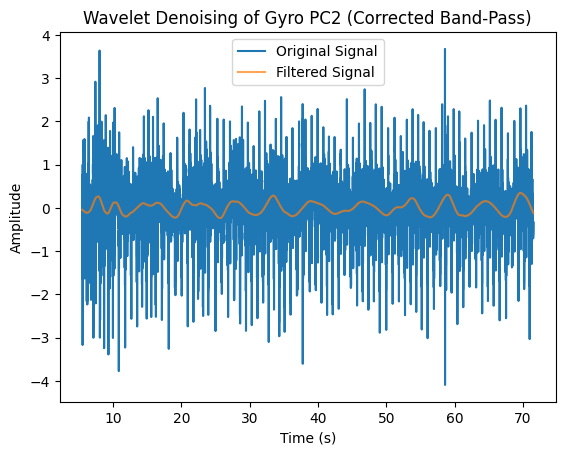

In [48]:
import pywt
import numpy as np
import matplotlib.pyplot as plt

J = 10

# 1. Perform Wavelet Decomposition (db6, level 10)
coeffs = pywt.wavedec(gyro2, "db6", level=J, axis=0)

# coeffs structure: [A10, D10, D9, D8, D7, D6, D5, D4, D3, D2, D1]
# Indices:          [0,   1,   2,  3,  4,  5,  6,  7,  8,  9,  10]

# 2. Remove DC Offset / Sensor Drift (Zero out A10)
coeffs[0] = np.zeros_like(coeffs[0]) 

# 3. Targeted High-Frequency Denoising 
# We keep D10 (index 1) and D9 (index 2) which contain the respiratory rate.
# We zero out everything from D8 (index 3) to D1 (index 10).
for i in range(3, J+1): 
    coeffs[i] = np.zeros_like(coeffs[i])

# 4. Reconstruct the filtered respiratory signal
filtered_sig = pywt.waverec(coeffs, "db6", axis=0)

# 5. Plotting
# Note: To visually ignore the edge effects, you can slice the arrays when plotting, 
# e.g., df['Time'][100:-100] and filtered_sig[100:-100] depending on your sample rate.
plt.plot(df['Time'], gyro2, label='Original Signal')
plt.plot(df['Time'], filtered_sig[:df.shape[0]], label='Filtered Signal', alpha=0.7)
plt.title('Wavelet Denoising of Gyro PC2 (Corrected Band-Pass)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

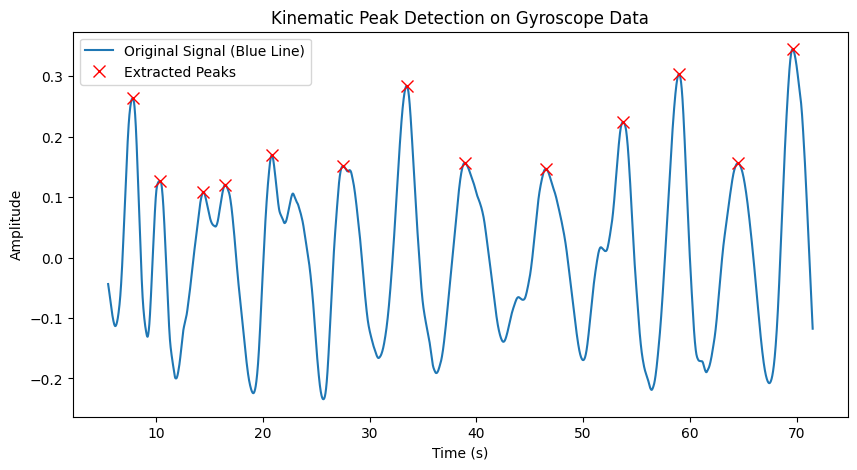

In [49]:
from scipy.signal import find_peaks

signal_to_analyze = filtered_sig[:df.shape[0]]  # Ensure we only analyze the portion of the signal that corresponds to our time vector

# Estrazione dei picchi
# I valori qui sotto sono indicativi basandomi sul tuo grafico blu:
# - height=1.0: scarta tutto ciò che sta sotto ampiezza 1
# - prominence=0.5: il picco deve emergere di almeno 0.5 dal suo intorno locale
# - distance=20: impone un numero minimo di campioni (non secondi!) tra un picco e l'altro
peaks, properties = find_peaks(signal_to_analyze, height=0.1, prominence=0.05, distance=10)

# Plotting per verifica visiva
plt.figure(figsize=(10, 5))
plt.plot(df['Time'], signal_to_analyze, label='Original Signal (Blue Line)')

# 'peaks' contiene gli INDICI dell'array, non i tempi in secondi. 
# Usiamo questi indici per pescare i tempi e le ampiezze corrispondenti.
plt.plot(df['Time'].iloc[peaks], signal_to_analyze[peaks], "x", color='red', markersize=8, label='Extracted Peaks')

plt.title('Kinematic Peak Detection on Gyroscope Data')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

In [28]:
t = df['Time'].iloc[peaks].values
dt = [t[i+1] - t[i] for i in np.arange(0, len(t)-1, 2)]
avg = np.mean(dt)
std = np.std(dt)/np.sqrt(len(dt))  # Standard error of the mean
print(f'Average time between peaks: {avg:.2f} seconds')
print(f'Frequency {1/(avg):.3f} +- {1/(avg**2)*std:.3f} Hz')

Average time between peaks: 0.91 seconds
Frequency 1.099 +- 0.060 Hz
